In [114]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from MLPClass import Layer, MLP
import tensorflow_hub as hub

In [115]:
# input type
def detect_input_type(file_path):
    file_path = file_path.lower()
    if file_path.endswith((".png", ".jpg", ".jpeg")):
        return "image"
    elif file_path.endswith(".txt"):
        return "text"
    else:
        raise ValueError("Unsupported file type!")

# load pretrained model (inceptionv1)
def load_imagenet_model():
    hub_layer = hub.KerasLayer(
        'https://tfhub.dev/google/imagenet/inception_v1/classification/4',
        trainable=False
    )
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Lambda(lambda x: hub_layer(x)))
    model.build([None, 224, 224, 3])
    return model

# preprocess img for imgnet model
def preprocess_image_for_imagenet(image):
    image = tf.image.resize(image, (224, 224))
    image = image / 255.0
    image = tf.expand_dims(image, 0)
    return image

# model dispatcher
def get_model(file_type, **kwargs):
    if file_type == "image":
        return load_imagenet_model()
    elif file_type == "text":
        return MLP(**kwargs)
    else:
        raise ValueError("Cannot recognize file type!")

In [116]:
def interpolate_images(baseline, image, alphas):
    baseline = tf.cast(baseline, tf.float32)
    image = tf.cast(image, tf.float32)
    alphas_x = alphas[:, None, None, None] # (m_steps, 1,1,1)
    delta = image - baseline
    return baseline + alphas_x * delta # (m_steps, 224,224,3)

def compute_gradients(model, images, target_class_idx):
    with tf.GradientTape() as tape:
        tape.watch(images)
        logits = model(images)
        probs = tf.nn.softmax(logits, axis=-1)[:, target_class_idx]
    return tape.gradient(probs, images)

def integral_approximation(gradients):
    grads = (gradients[:-1] + gradients[1:]) / 2.0
    return tf.reduce_mean(grads, axis=0)

def integrated_gradients(model, image, target_class_idx, m_steps=50):
    baseline = tf.zeros_like(image)
    alphas = tf.linspace(0.0, 1.0, m_steps + 1)
    interpolated_images = interpolate_images(baseline, image, alphas)
    gradients = compute_gradients(model, interpolated_images, target_class_idx)
    avg_gradients = integral_approximation(gradients)
    ig = (image - baseline) * avg_gradients
    return ig

17858/17858 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step


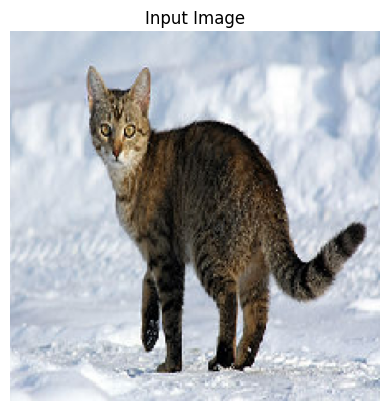

In [120]:
# sampleimg
image_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg"
image_path = tf.keras.utils.get_file("cat.jpg", image_url)
img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# load labels
labels_path = tf.keras.utils.get_file(
    'ImageNetLabels.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt'
)
imagenet_labels = np.array(open(labels_path).read().splitlines())

# input img
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

# get file type to 
file_type = detect_input_type(image_path)
image_model = get_model(file_type)

In [121]:
# sample text
texts = [
    "I love texting",
    "This is ugly",
    "Amazing experience",
    "Worst food ever",
    "Television makes me happy",
    "I like to draw",
    "Sushi is disgusting",
]
labels = [1, 0, 1, 0] # sample labels

# TF-IDF vectorization
text_vectorizer = TfidfVectorizer()
X_text = text_vectorizer.fit_transform(texts).toarray()
y_text = np.array(labels)

In [122]:
# layers for text model
layers_list = [
    Layer(input_shape=(X_text.shape[1],), neurons=8, activation="relu"),
    Layer(neurons=2, activation="softmax")
]

text_model = MLP(
    model_input=X_text,
    model_output=y_text,
    layers=layers_list
)

text_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

text_model.fit(X_text, y_text, epochs=10)

<Sequential name=sequential_45, built=False>


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 7
'y' sizes: 4


In [123]:
# show img + ig overlay
def show_image_with_ig(image, ig, title="IG Overlay"):
    image = tf.squeeze(image) # remove batch dimensions
    ig = tf.squeeze(ig)
    image = image.numpy() # convert to numpy
    ig = ig.numpy()
    ig = np.sum(np.abs(ig), axis=-1) # single heatmap
    ig = (ig - ig.min()) / (ig.max() - ig.min() + 1e-8) # normalize

    plt.figure(figsize=(6,6))
    plt.imshow(ig,cmap='inferno')
    plt.title("Integrated Gradients Heatmap")
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(ig, cmap='jet', alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

# gen prediction
def predict_input(input_data, input_type):
    print("\n=== PREDICT INPUT CALLED ===")
    print("DEBUG input_type:", input_type)

    if input_type == "image":
        print("Running IMAGE pipeline...")
        img = tf.convert_to_tensor(input_data[0], dtype=tf.float32) # getimg
        img_proc = preprocess_image_for_imagenet(img) # preprocess
        image_model = load_imagenet_model()
        preds = image_model(img_proc)
        pred_idx = tf.argmax(preds[0]).numpy()

        print("Predicted index:", pred_idx)
        print("Predicted label:", imagenet_labels[pred_idx])

        ig = integrated_gradients(
            image_model,
            img,
            target_class_idx=pred_idx,
            m_steps=50
        )
        show_image_with_ig(img, ig, title=imagenet_labels[pred_idx])

    elif input_type == "text":
        print("Now running TEXT pipeline.")
        X_test = text_vectorizer.transform(input_data).toarray()
        pred = text_model.predict(X_test)
        pred_class = np.argmax(pred)
        print("Prediction for text:", pred_class)
    else:
        print("Sorry, this is an unknown input type!")


=== PREDICT INPUT CALLED ===
DEBUG input_type: image
Running IMAGE pipeline...
Predicted index: 112
Predicted label: nematode


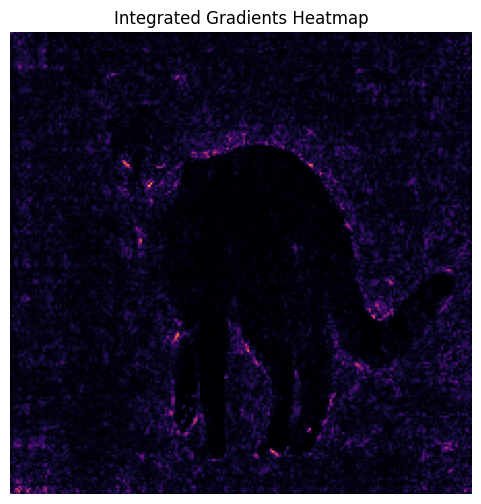

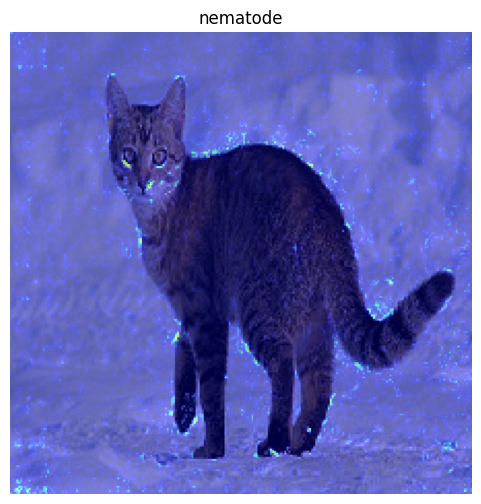


=== PREDICT INPUT CALLED ===
DEBUG input_type: text
Now running TEXT pipeline.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction for text: 1


In [124]:
predict_input([img_array[0]], "image")
predict_input(["I love this"], "text")